In [38]:
import numpy as np
import networkx as nx
from grakel import GraphKernel
import matplotlib.pyplot as plt
import seaborn as sns
from torch_geometric.utils import to_networkx
from sklearn.metrics.pairwise import cosine_similarity
from networkx.algorithms import community

In [34]:
from torch_geometric.datasets import TUDataset
tu_data = TUDataset(root="tutorial1",name= "Yeast")
# https://pytorch-geometrimport networkx as nx
t1 = tu_data[1]
len(t1)

4

In [35]:
G1 = to_networkx(t1, node_attrs=["x"], edge_attrs=["edge_attr"])

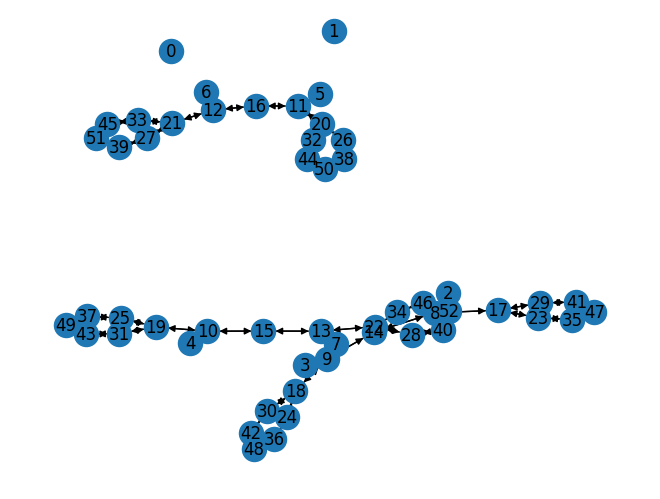

In [36]:
nx.draw(G1, with_labels = True)
plt.show()

### Community Detection: identify subgroups of vertices (communities)

In [40]:
curvature = {node: np.random.uniform(0, 1) for node in G1.nodes()}  # Example curvature dictionary

communities = community.greedy_modularity_communities(G1)


average_curvature_array = np.array(average_curvature_per_community).reshape(-1, 1)


### Compute Average Curvature for Each Community

In [39]:
average_curvature_per_community = []
for comm in communities:
    # Compute average curvature
    community_curvatures = [curvature[node] for node in comm]
    avg_curvature = np.mean(community_curvatures)
    average_curvature_per_community.append(avg_curvature)

for i, avg_curvature in enumerate(average_curvature_per_community):
    print(f"Average curvature for community {i + 1}: {avg_curvature}")

Average curvature for community 1: 0.44676849992940487
Average curvature for community 2: 0.517218624352869
Average curvature for community 3: 0.6034045840649178
Average curvature for community 4: 0.41702090347339693
Average curvature for community 5: 0.3270080181253983
Average curvature for community 6: 0.5030178534445896
Average curvature for community 7: 0.3656517964707898
Average curvature for community 8: 0.38479054415236746
Average curvature for community 9: 0.19797030847463976
Average curvature for community 10: 0.62957018925282
Average curvature for community 11: 0.9833225619297964


### Compute the cosine similarity between the averaged curvature vectors of each pair of communities.

In [41]:
cosine_sim_matrix = cosine_similarity(average_curvature_array)
print("Cosine Similarity Matrix:")
print(cosine_sim_matrix)

Cosine Similarity Matrix:
[[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]]
